## Skin Disease Multiclass Classification

## 1. Project Overview
- **Project:** Skin Disease Multiclass Classification
- **Data:** Clinical patient information
- **Technology:** Python and Machine Learning,NumPy, Matplotlib, Seaborn, Scikit-learn
- **Model:** Logistic Regression,SVC,Decision Tree,Random Forest,XGBoost
- **Prediction:** Six different skin disease classes
- **Techniques:** EDA, preprocessing, SMOTE, model building and hyperparameter tuning
- **Purpose:** To support early identification of skin diseases and assist doctors in the diagnostic proces

## 2. Problem Statement

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a predictive model  using machine learning techniques to predict the various classes of skin disease. 

Task3:-Suggestions to the Doctors to identify the skin diseases of the patient at the earliest. 

## 3. Importing Libraries

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix,classification_report

In [2]:
## load the data
df=pd.read_csv(r"data\dataset_35_dermatology .csv")
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


## 4. Basic checks

In [3]:
# shape of dataset
df.shape

(366, 35)

In [4]:
# check missng values
df.isnull().sum().sum()

np.int64(0)

In [5]:
# columns in the dataset
df.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [7]:
# check duplicated values
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [9]:
# target column values count
df['class'].value_counts()

class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

In [10]:
# normalizing the target class values
df['class'].value_counts(normalize=True)*100

class
1    30.601093
3    19.672131
2    16.666667
5    14.207650
4    13.387978
6     5.464481
Name: proportion, dtype: float64

## 5. Handling missing values

In [11]:
#replacing the ? with Nan
df.replace("?", np.nan, inplace=True)

# Convert Age column to numeric
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

In [12]:
# imputing age values with mode 
imputer=SimpleImputer(strategy='most_frequent')
df['Age']=imputer.fit_transform(df[['Age']])

## Task 1: Complete Data Analysis Report

**Observations:**
- The dataset contains 6 target classes: 1, 2, 3, 4, 5, and 6.
- The class distribution is imbalanced. Class 1 has the highest number of records (112, approximately 30.60%), while Class 6 has the lowest number of records (20, approximately 5.46%).
- The presence of unequal class frequencies indicates that class imbalance should be considered during model development and evaluation.
- Missing values represented by the symbol "?" were identified and replaced with NaN.
- The Age column was converted into a numeric data type using pd.to_numeric(), with invalid values converted to NaN.
- Missing values in the Age column were handled using the most frequent value (mode) through SimpleImputer.

**Overall Insight:** The dataset required preprocessing to handle missing and invalid values, and the target variable shows class imbalance, which may affect the performance of the machine learning model.

## 6. EDA

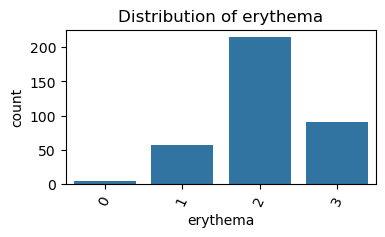

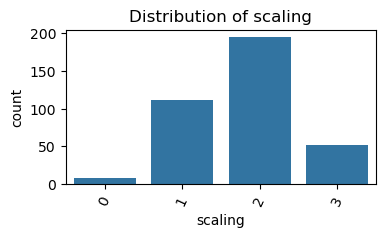

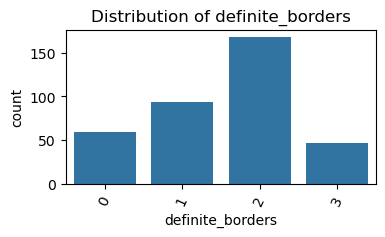

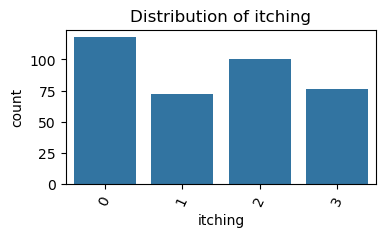

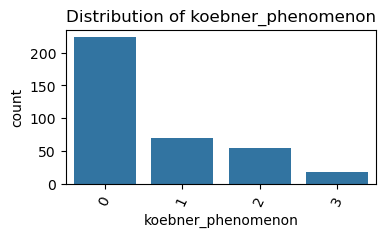

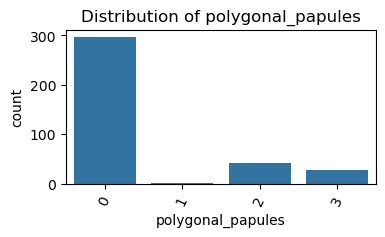

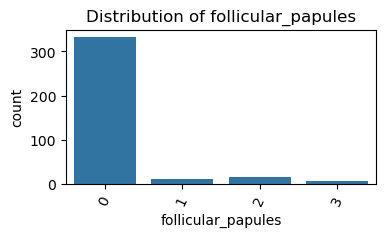

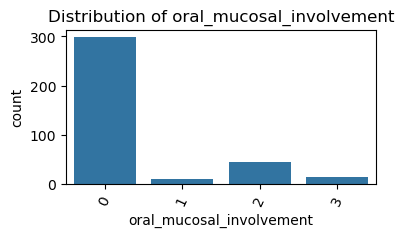

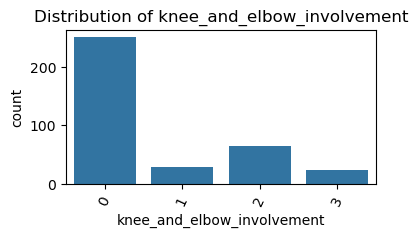

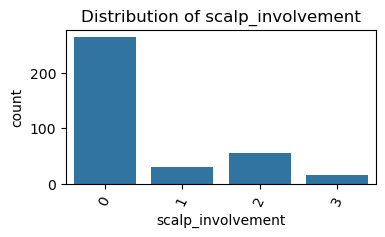

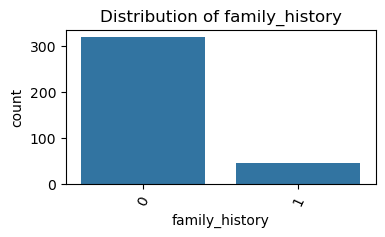

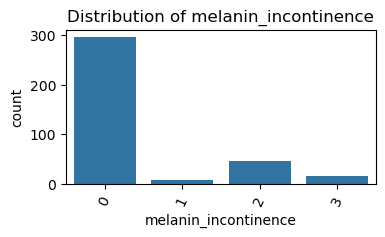

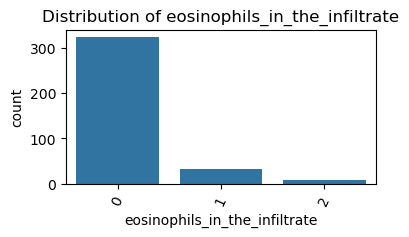

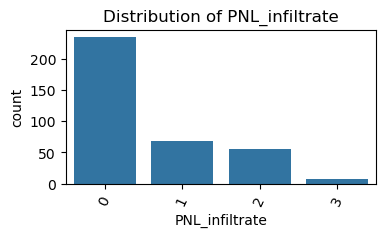

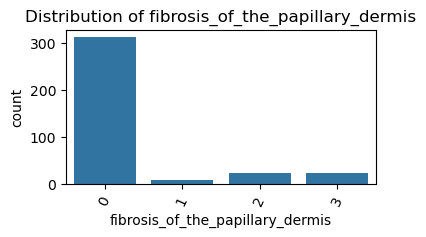

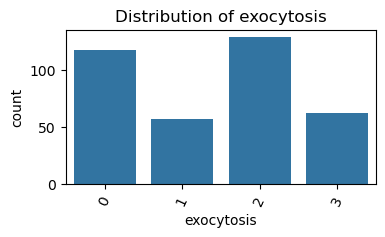

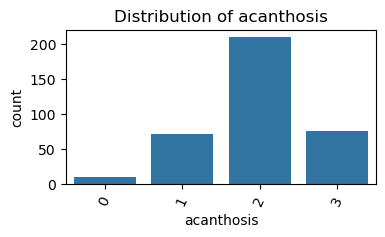

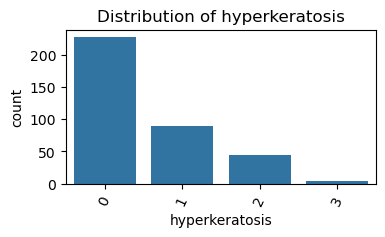

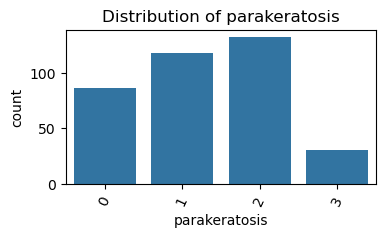

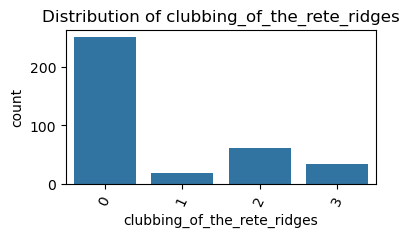

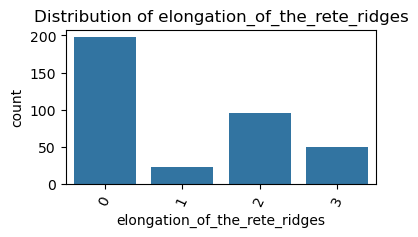

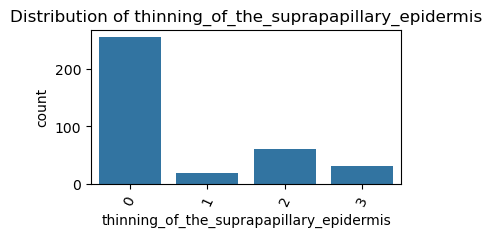

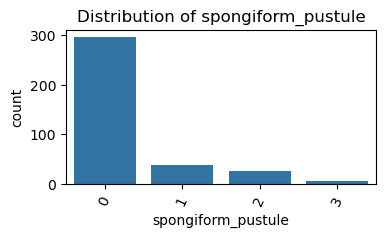

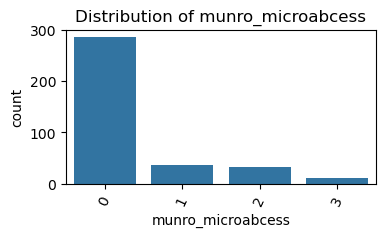

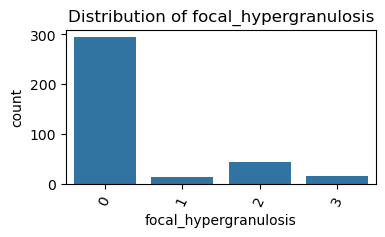

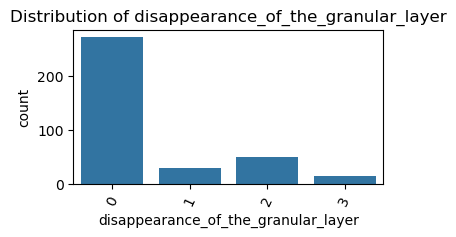

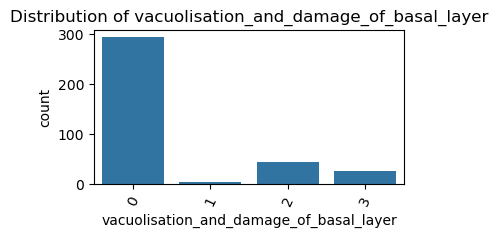

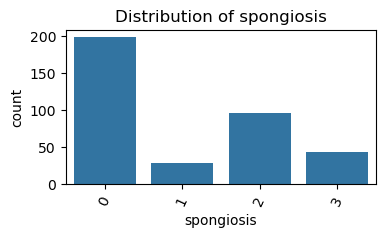

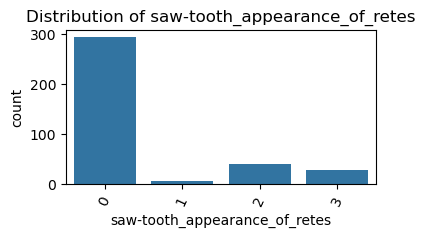

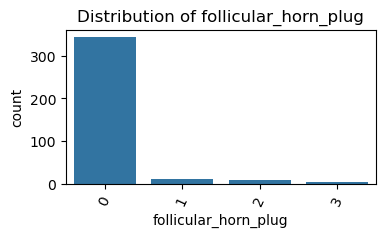

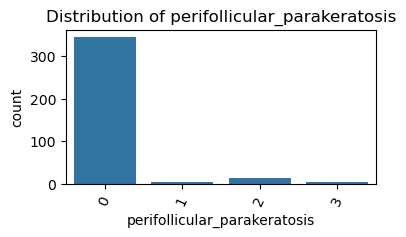

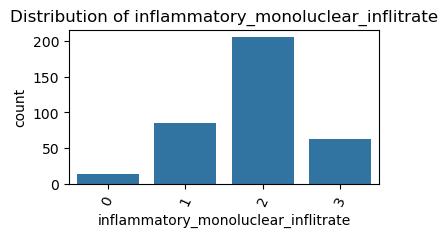

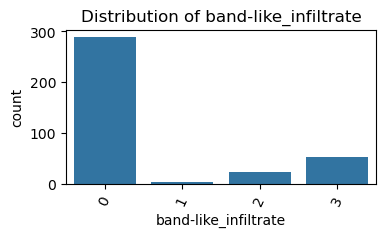

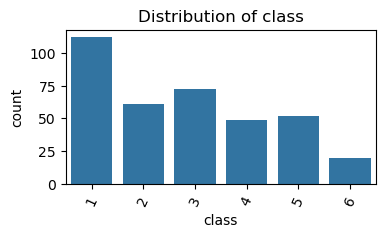

In [13]:
## univariate analysis
num_cols=df.select_dtypes(include=['int64']).columns
for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=65)
    plt.show()

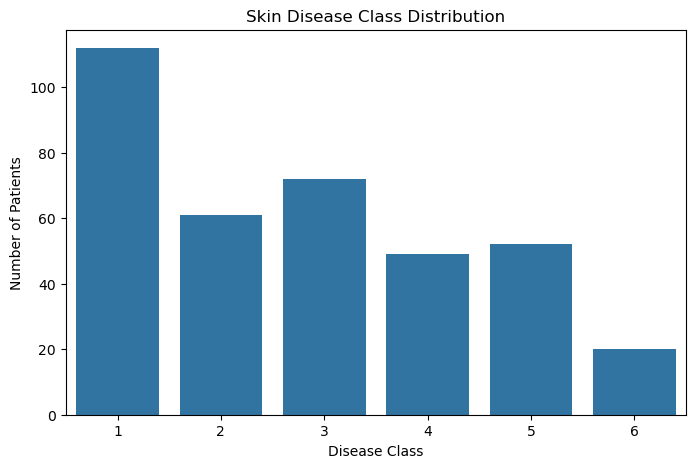

,class,count,percentage
0,1,112,30.601093
1,2,61,16.666667
2,3,72,19.672131
3,4,49,13.387978
4,5,52,14.207650
5,6,20,5.464481


In [14]:
# Class-wise distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='class')
plt.title('Skin Disease Class Distribution')
plt.xlabel('Disease Class')
plt.ylabel('Number of Patients')
plt.show()

class_summary = df['class'].value_counts().sort_index().rename_axis('class').reset_index(name='count')
class_summary['percentage'] = class_summary['count'] / len(df) * 100
display(class_summary)

## Observation:
- The target variable class contains six skin disease classes with a total of 366 observations.  
- Class 1 has the highest number of observations with 112 patients (30.60%), whereas Class 6 has the lowest number with only 20 patients (5.46%).
- Classes 2 and 3 contain 61 and 72 observations respectively, while Classes 4 and 5 contain 49 and 52 observations. 
- Therefore, the dataset has an uneven class distribution, which should be considered during model development. 
- The distribution of the classes is imbalanced.To reduce the potential bias toward majority classes, class balancing techniques can be applied to       the training data.

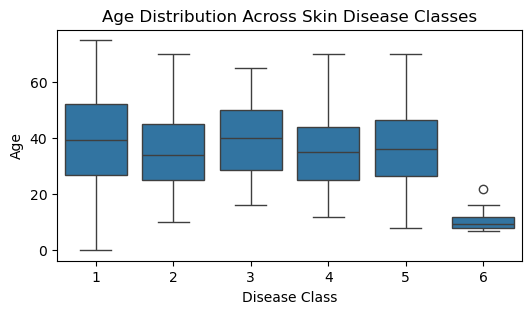

,count,mean,median,min,max
class,,,,,
1,112,39.38,39.5,0.0,75.0
2,61,35.54,34.0,10.0,70.0
3,72,39.96,40.0,16.0,65.0
4,49,35.37,35.0,12.0,70.0
5,52,36.92,36.0,8.0,70.0
6,20,10.25,9.5,7.0,22.0


In [15]:
# Age analysis by disease class
plt.figure(figsize=(6,3))
sns.boxplot(data=df, x='class', y='Age')
plt.title('Age Distribution Across Skin Disease Classes')
plt.xlabel('Disease Class')
plt.ylabel('Age')
plt.show()

display(df.groupby('class')['Age'].agg(['count','mean','median','min','max']).round(2))

## Observation:
- The age distribution varies across the six skin disease classes.
- Classes 1–5 have median ages between approximately 34 and 40 years, whereas Class 6 has a much lower median age of 9.5 years.
- This indicates that age may help distinguish between some disease classes and can therefore be considered an important feature during predictive      modeling.

## 6.2 Bivariate Analysis

In [16]:
#Bivariate Analysis: Clinical Features vs Disease Class
clinical_features = ['erythema',
    'scaling',
    'definite_borders',
    'itching',
    'koebner_phenomenon',
    'polygonal_papules',
    'oral_mucosal_involvement',
    'scalp_involvement']
class_feature_means = df.groupby('class')[clinical_features].mean()
display(class_feature_means.round(2))

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,oral_mucosal_involvement,scalp_involvement
class,,,,,,,,
1,2.29,2.20,2.10,0.95,0.67,0.00,0.00,1.53
2,2.28,2.07,0.95,1.62,0.03,0.00,0.00,0.11
3,2.08,1.62,2.10,2.28,1.35,2.28,1.92,0.03
4,1.90,1.51,1.18,0.47,1.18,0.00,0.00,0.00
5,1.50,1.13,0.85,1.88,0.00,0.00,0.00,0.00
6,2.05,1.75,1.05,0.50,0.00,0.00,0.00,0.50


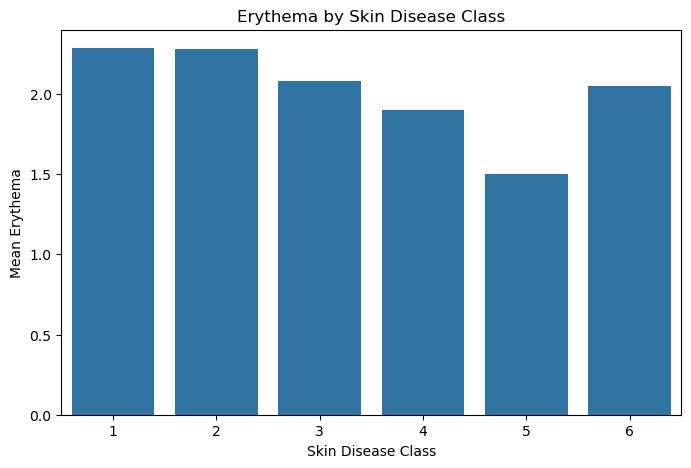

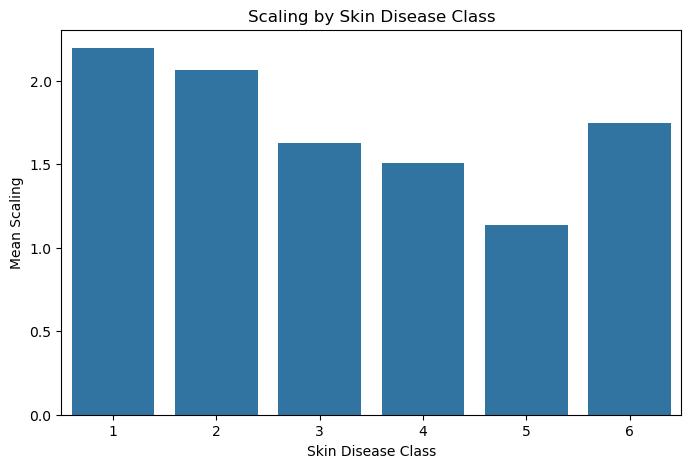

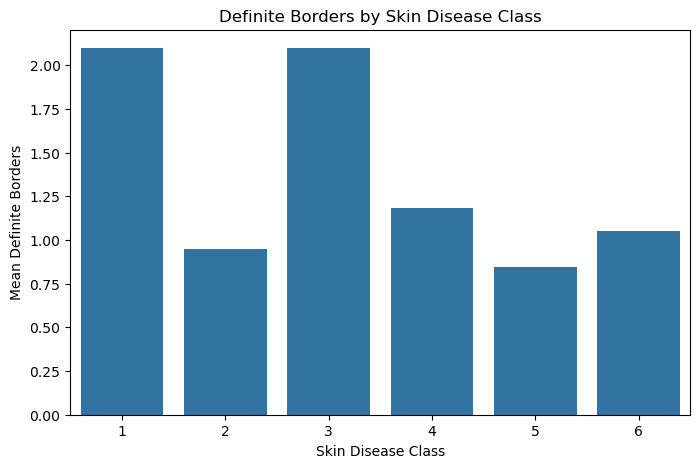

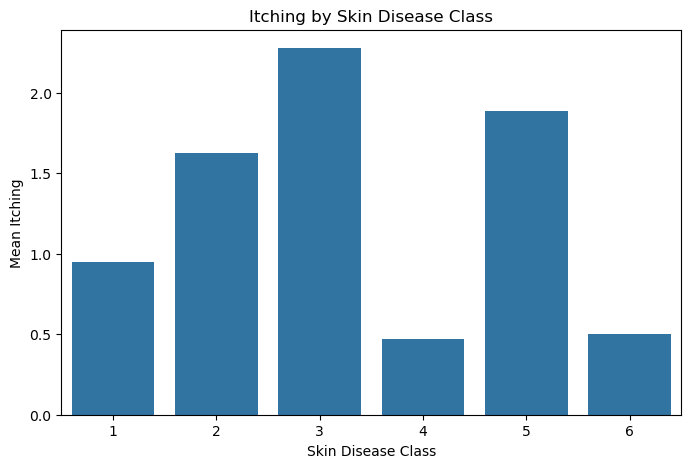

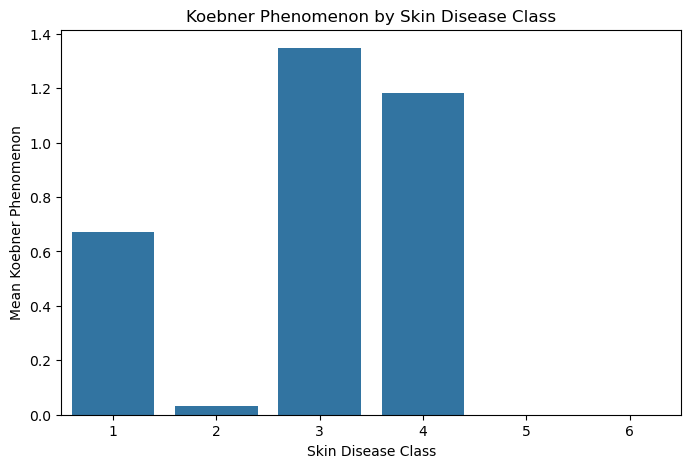

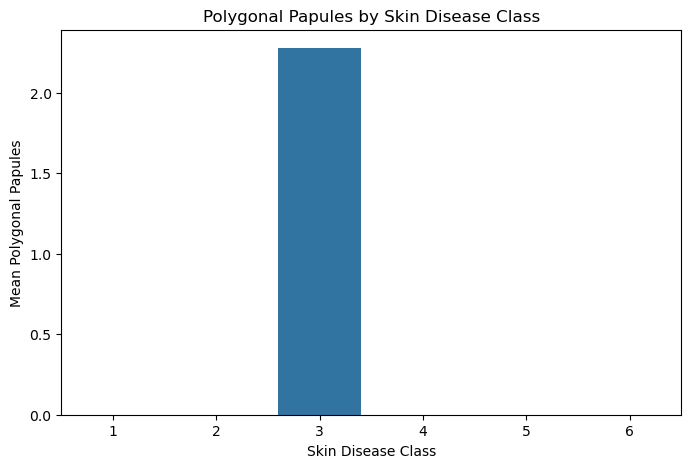

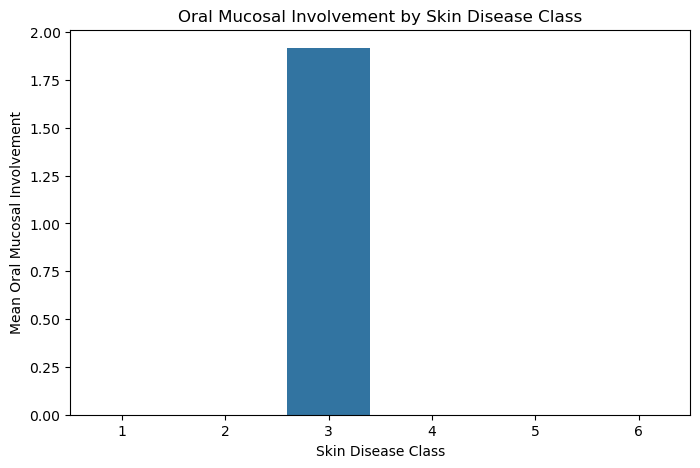

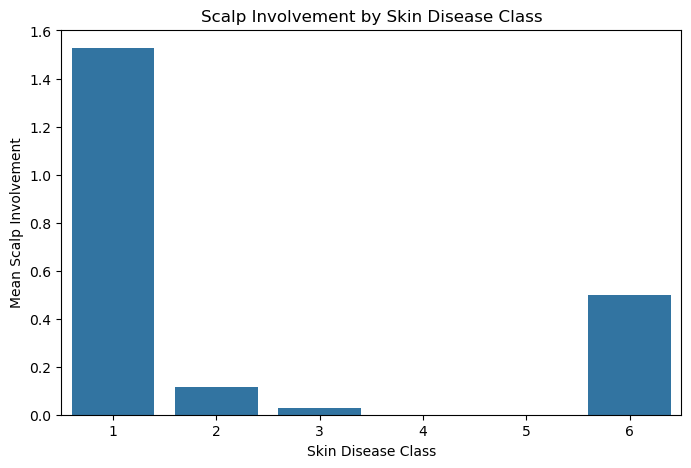

In [17]:
# plot clinical_feature
for feature in clinical_features:
    plt.figure(figsize=(8,5))
    sns.barplot(data=df,x='class',y=feature,errorbar=None)
    plt.title(f'{feature.replace("_", " ").title()} by Skin Disease Class')
    plt.xlabel('Skin Disease Class')
    plt.ylabel(f'Mean {feature.replace("_", " ").title()}')
    plt.show()

## 6.3 Correlation Analysis 

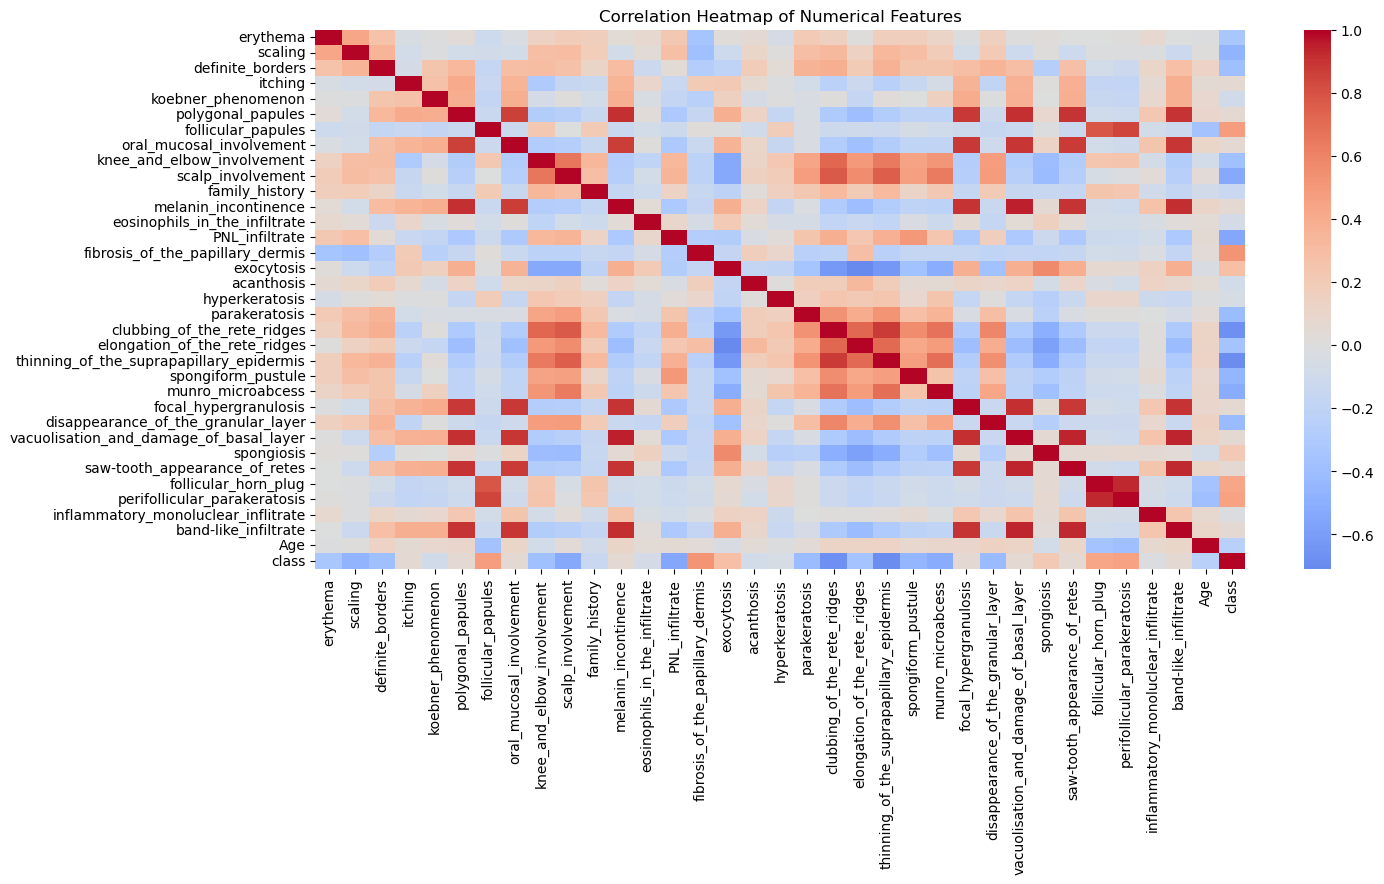

In [18]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(15,7))
sns.heatmap(numeric_df.corr(),cmap='coolwarm',center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Task 1: Report conclusion

- The dataset has 366 records and 35 columns.
- There are 34 predictor columns and one target column, `class`.
- The target contains six disease classes.
- Class 1 is the largest class (112 records; 30.60%) and Class 6 is the smallest class (20 records; 5.46%), so the target is imbalanced.
- checked duplicates and reports zero duplicates.
- replaced `?` with missing values and converts `Age` to numeric; missing Age values are imputed using the median.
- perform univariate analysis. The added cells provide the missing class-wise, age-wise and correlation analysis.
- Because the classes are imbalanced, model evaluation should not rely on accuracy alone; macro precision, macro recall and macro F1-score should       also be reported.

## Task 2: Predictive Model for Skin Disease Classes

Create a Predictive Model Using Machine Learning Techniques

## 7. Preprocessing

In [19]:
# defining features and target 
x=df.drop('class',axis=1)
y=df['class']

In [20]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [21]:
print(np.unique(y))

[0 1 2 3 4 5]


## 8. Train-Test-Split

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

## 9. Scaling

In [23]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## 10. Smoothig

In [24]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train_scaled,y_train)

## 11. Model Building

## Logisctic Regression

In [25]:
lr=LogisticRegression(max_iter=100)
lr.fit(x_train_balanced,y_train_balanced)
lr_pred=lr.predict(x_test_scaled)
lr_proba=lr.predict_proba(x_test_scaled)
print("Accuracy:",accuracy_score(lr_pred,y_test))
print(classification_report(lr_pred,y_test))

Accuracy: 0.9594594594594594
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.83      1.00      0.91        10
           2       0.93      1.00      0.97        14
           3       1.00      0.77      0.87        13
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.96      0.96        74
weighted avg       0.96      0.96      0.96        74



# Random Forest

In [26]:
smote = SMOTE(random_state=42)
x_train_rf_balanced, y_train_rf_balanced = smote.fit_resample(x_train,y_train)
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train_rf_balanced, y_train_rf_balanced)
rf_pred = rf.predict(x_test)
rf_proba=rf.predict_proba(x_test)
print("Accuracy:",accuracy_score(rf_pred,y_test))
print(classification_report(rf_pred,y_test))

Accuracy: 0.9459459459459459
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.75      0.90      0.82        10
           2       1.00      1.00      1.00        15
           3       0.90      0.82      0.86        11
           4       1.00      1.00      1.00        10
           5       1.00      0.80      0.89         5

    accuracy                           0.95        74
   macro avg       0.94      0.92      0.93        74
weighted avg       0.95      0.95      0.95        74



## 12. Hyperparameter tuning on Random Forest

In [27]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))])

In [28]:
param_dist = {'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [10, 20, 30, 50, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__bootstrap': [True, False]}

# 13. Evaluation of Hyperparameter Tuning on Random forest 

In [29]:
random_search = RandomizedSearchCV(
    estimator=pipeline,param_distributions=param_dist,n_iter=30,cv=5,scoring='f1_macro',n_jobs=-1,random_state=42,verbose=2)
random_search.fit(x_train, y_train)
best_rf = random_search.best_estimator_
tuned_rf_pred = best_rf.predict(x_test)
print("Best Parameters:")
print(random_search.best_params_)
print("\nBest CV Macro F1:")
print(random_search.best_score_)
print("\nTest Accuracy:")
print(accuracy_score(y_test, tuned_rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, tuned_rf_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'rf__n_estimators': 500, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 4, 'rf__max_features': 'log2', 'rf__max_depth': 10, 'rf__bootstrap': True}

Best CV Macro F1:
0.9731957069418369

Test Accuracy:
0.972972972972973

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.92      0.92      0.92        12
           2       1.00      1.00      1.00        15
           3       1.00      0.90      0.95        10
           4       1.00      1.00      1.00        10
           5       0.80      1.00      0.89         4

    accuracy                           0.97        74
   macro avg       0.95      0.97      0.96        74
weighted avg       0.98      0.97      0.97        74



## Decision Tree

In [30]:
dt=DecisionTreeClassifier()
x_train_dt_balanced,y_train_dt_balanced = smote.fit_resample(x_train,y_train)
dt.fit(x_train_dt_balanced,y_train_dt_balanced)
dt_pred=dt.predict(x_test)
dt_proba=dt.predict_proba(x_test)
print("Accuracy:",accuracy_score(dt_pred,y_test))
print(classification_report(dt_pred,y_test))

Accuracy: 0.9324324324324325
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.75      0.90      0.82        10
           2       0.93      1.00      0.97        14
           3       0.90      0.82      0.86        11
           4       1.00      0.91      0.95        11
           5       1.00      0.80      0.89         5

    accuracy                           0.93        74
   macro avg       0.93      0.90      0.91        74
weighted avg       0.94      0.93      0.93        74



## SVC

In [31]:
svc=SVC()
svc.fit(x_train_balanced,y_train_balanced)
svc_pred=svc.predict(x_test_scaled)
print("Accuracy:",accuracy_score(svc_pred,y_test))
print(classification_report(svc_pred,y_test))

Accuracy: 0.9594594594594594
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.83      0.91      0.87        11
           2       1.00      1.00      1.00        15
           3       0.90      0.82      0.86        11
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.95      0.95        74
weighted avg       0.96      0.96      0.96        74



## XGBoost

In [32]:
xgb=XGBClassifier(random_state=42)
x_train_xgb_balanced, y_train_xgb_balanced = smote.fit_resample(x_train,y_train)
xgb.fit(x_train_xgb_balanced,y_train_xgb_balanced)
xgb_pred=xgb.predict(x_test)
xgb_proba=xgb.predict_proba(x_test)
print("Accuracy:",accuracy_score(xgb_pred,y_test))
print(classification_report(xgb_pred,y_test))

Accuracy: 0.918918918918919
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.67      0.89      0.76         9
           2       0.93      1.00      0.97        14
           3       0.90      0.69      0.78        13
           4       1.00      0.91      0.95        11
           5       1.00      1.00      1.00         4

    accuracy                           0.92        74
   macro avg       0.92      0.92      0.91        74
weighted avg       0.93      0.92      0.92        74



In [33]:
result=pd.DataFrame({
    "Model":["LogisticRegression",
             "DecisionTreeClassifier",
             "RandomForestClassifier",
             "SVC","XGBClassifier"],
    "Accuracy":[accuracy_score(y_test,lr_pred),
                accuracy_score(y_test,dt_pred),
                accuracy_score(y_test,rf_pred),
                accuracy_score(y_test,svc_pred),
                accuracy_score(y_test,xgb_pred)]})
result=result.sort_values(by="Accuracy",ascending=False)
print(result)

                    Model  Accuracy
0      LogisticRegression  0.959459
3                     SVC  0.959459
2  RandomForestClassifier  0.945946
1  DecisionTreeClassifier  0.932432
4           XGBClassifier  0.918919


In [34]:
# Create comparison DataFrame
result = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "SVC",
        "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_rf_pred),
        accuracy_score(y_test, svc_pred),
        accuracy_score(y_test, xgb_pred)],
    "Macro Precision": [
        precision_score(y_test, lr_pred, average='macro'),
        precision_score(y_test, dt_pred, average='macro'),
        precision_score(y_test, rf_pred, average='macro'),
        precision_score(y_test, tuned_rf_pred, average='macro'),
        precision_score(y_test, svc_pred, average='macro'),
        precision_score(y_test, xgb_pred, average='macro')],
    "Macro Recall": [
        recall_score(y_test, lr_pred, average='macro'),
        recall_score(y_test, dt_pred, average='macro'),
        recall_score(y_test, rf_pred, average='macro'),
        recall_score(y_test, tuned_rf_pred, average='macro'),
        recall_score(y_test, svc_pred, average='macro'),
        recall_score(y_test, xgb_pred, average='macro')],
    "Macro F1 Score": [
        f1_score(y_test, lr_pred, average='macro'),
        f1_score(y_test, dt_pred, average='macro'),
        f1_score(y_test, rf_pred, average='macro'),
        f1_score(y_test, tuned_rf_pred, average='macro'),
        f1_score(y_test, svc_pred, average='macro'),
        f1_score(y_test, xgb_pred, average='macro')]})
# Sort based on Macro F1 Score
result = result.sort_values(
    by="Macro F1 Score",
    ascending=False)
# Reset index
result = result.reset_index(drop=True)
# Display results
result.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1 Score
0,Tuned Random Forest,0.9730,0.9528,0.9694,0.9588
1,Logistic Regression,0.9595,0.9615,0.9611,0.9574
2,SVC,0.9595,0.9545,0.9556,0.9545
3,Random Forest,0.9459,0.9197,0.9417,0.9274
4,Decision Tree,0.9324,0.9045,0.9306,0.9137
5,XGBoost,0.9189,0.9150,0.9167,0.9104


## 15. Accuracy Comparison Plot

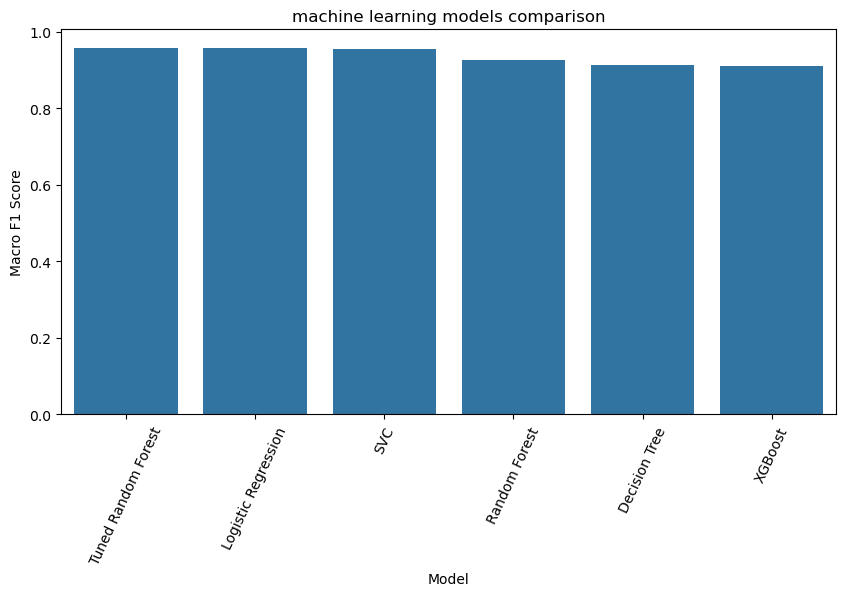

In [37]:
plt.figure(figsize=(10,5))
sns.barplot(data=result,x="Model",y="Macro F1 Score")
plt.xticks(rotation=65)
plt.title("machine learning models comparison")
plt.show()

## task-2:Report Conclusion
* The skin disease classification model successfully classified six different disease classes using machine learning techniques. After hyperparameter tuning, the Random Forest model achieved a test **accuracy of 97.30%** and a cross-validation **Macro F1-score of 95.88%**. 
* The Tuned Random Forest model was selected as the best-performing model for skin disease prediction. It achieved the highest accuracy of 97.30% and the highest Macro F1-score of 95.88%, demonstrating better overall and balanced performance across all disease classes.

Although Logistic Regression has slightly higher Macro Precision (96.15%), but Tuned Random Forest has:

- Highest Accuracy → 97.30%
- Highest Macro Recall → 96.94%
- Highest Macro F1 Score → 95.88%

Since the dataset is a multiclass and imbalanced skin disease dataset, Macro F1 Score is an important metric because it gives equal importance to all disease classes.

## Task - 3: Suggestions to Doctors for Early Identification

This machine-learning model should be treated as a **clinical decision-support tool**, not as a replacement for a dermatologist's diagnosis.

1. **Collect the clinical features early:** Record the patient's observed symptoms and clinical/histopathological findings represented by the dataset, such as erythema, scaling, itching, definite borders, scalp involvement and other recorded features.
2. **Use the model as an early screening aid:** Enter the patient's available feature values into the trained model to obtain a predicted disease class and use the result to support further clinical assessment.
3. **Pay attention to uncertain or borderline cases:** If the model's predicted probabilities are close across multiple classes, the case should receive additional clinical examination rather than relying on the top prediction alone.
4. **Do not ignore rare classes:** Class 6 has only 20 records in the dataset, compared with 112 records for Class 1. Doctors should therefore be particularly cautious when the model predicts a less-represented class and should confirm it clinically.
5. **Use confusion-matrix results to identify commonly confused classes:** The model evaluation should be reviewed to determine which disease classes are most frequently confused and where additional clinical checks may be useful.
6. **Confirm the prediction clinically:** A dermatologist should combine the model output with patient history, physical examination and appropriate diagnostic tests before making a final diagnosis or treatment decision.
7. **Monitor model performance over time:** If this system is deployed, performance should be periodically re-evaluated on new, clinically representative data.